# 03 Machine Learning Workflow dengan Scikit-Learn

## Persiapan Dataset

Salah satu fase yang sangat krusial dalam Machine Learning Workflow adalah **persiapan Dataset**. Ketika kita bekerja dengan _real data_ di lapangan, fase ini bisa jadi fase yang membutuhkan paling banyak waktu dan juga effort. Untuk kasus disini **saya mencoba menyederhanakan prosesnya dengan memanfaatkan sampel dataset yang sudah disediakan oleh Scikit-Learn**. Disini untuk menyederhanakan proses, saya akan menggunakan Iris Dataset yang sudah kita pelajari pada sesi sebelumnya.

Dan disini kita coba untuk melakukan proses import dulu dengan cara 

In [1]:
from sklearn.datasets import load_iris

lalu kita akan load data irisnya dan kita simpan dalam variable `iris`

In [2]:
iris = load_iris()

Tahapan berikutnya kita akan ekstrak sekumpulan nilai features dan juga sekumpulan nilai target dari dataset. 

Nah untuk nilai features-nya kita tampung dalam variable `X` dan nilai target-nya kita tampung dalam variable `y`.

In [3]:
X = iris.data
y = iris.target

---

## Splitting Dataset : Training & Testing Dataset

Nah setelah dataset-nya di load, selanjutnya bisa kita bagi dataset ini menjadi dua bagian. Atau istilahnya adalah kita melakukan **splitting dataset**. Dataset ini akan kita split menjadi Training Set dan Testing Set. Di Sesi pembelajaran sebelumnya saya sudah mengetahui bahwa Scikit-Learn memfasilitasi kita dalam proses splitting, testing, dan training dataset ini. 

Disini kita tinggal import saja

In [4]:
from sklearn.model_selection import train_test_split

Lalu berikutnya kita akan kenakan proses training, test, split pada data ya. Pertama kita panggil fuctionnya (`train_test_split`) dan kita akan melewati 4 parameter

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size=0.4,
                                                   random_state=1)

Di dalam function `train_test_split` ada 4 parameter :
- parameter pertama atau **`X`**, berisi sekumpulan nilai features-nya
- parameter kedua atau **`y`**, berisi sekumpulan nilai target
- parameter ketiga atau **`test_size`** adalah ukuran dari testing set
    - yang kita atur nilainya $0.4$ yang berarti kita men-setting ukuran data test sebesar $40\%$ dari keseluruhan data
    - yang berarti juga data training tersisa $0.6$ atau $60\%$ dari keseluruhan data
- Lalu berikutnya untuk proses pengacakan atau `random_state`, kita akan menggunakan `random_state = 1`

Lalu dari function `train_test_split` ini akan menghasilkan 4 kumpulan nilai yang harus kita tampung ke dalam 4 variable. Yaitu : X_train, X_test, y_train dan y_test. 

Nah bagi kalian yang masih bingung atau kesulitan untuk memahami proses persiapan data set ini, saya menyarankan untuk menyimak notebook sebelumnya. Karena pada sesi pembelajaran sebelumnya saya sudah membahas function `train_test_split` cukup mendetail. 

---

## Training Model

- Pada Scikit-Learn, model Machine Learning dibentuk dari _class_ yang dikenal dengan istilah **estimator** atau _estimator class_ 
- Setiap estimator akan mengimplementasikan dua method utama yaitu, `fit()` dan `predict()`
- Method `fit()` digunakan untuk **melakukan training model**
- Method `predict` digunakan untuk **melakukan estimasi / prediksi** dengan **memanfaatkan trained model** atau menggunakan model yang sudah di training sebelumnya.

Untuk kasus kita kali ini, kita akan menggunakan KNN atau K-Nearest Neighbors sebagai Machine Learning Model. Model ini akan kita training dengan memanfaatkan training set yang sudah kita persiapkan sebelumnya. 

Nah, disini kita perlu import modelnya atau kita perlu _estimator class_-nya, disini kita akan menggunakan KNN. Caranya cukup kita ketikan :

In [6]:
from sklearn.neighbors import KNeighborsClassifier

Tahapan berikutnya, kita akan membentuk objek dari kelas KNN ini. Nah pembentukan proses objek model ini membutuhkan 1 buah parameter yaitu `n_neighbors`. 

Parameter ini dibutuhkan karena objek yang mau kita bentuk ini berasal dari K-Nearest Neighbors Classifier. Dimana kita perlu men-spesifikan jumlah neighborsnya atau jumlah tetangganya. Nah untuk kasus kita kali ini kita set jumlah neighbors-nya adalah 3. 

Lalu selanjutnya, objek model yang terbentuk akan kita tampung kedalam variable `model`.

In [7]:
model = KNeighborsClassifier(n_neighbors = 3)

Selanjutnya objek `model` ini akan kita training dengan menggunakan metode fit. Nah proses training yang nanti akan memanfaatkan training set (`X_train` dan `y_train`)

Dimana `X_train` ini berisi **sekumpulan nilai features untuk training set**, dan `y_train` ini berisi **sekumpulan nilai target** untuk si training set tadi

In [8]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Begitu model menjalanai proses training, makan model ini dikenal sebagai **trained model** atau model yang sudah di training.

> Tapi sebagian dari kalian mungkin bakal bertanya-tanya apa itu Model K-Nearest Neighbors? ga perlu khawatir. Di sesi selanjutnya saya akan bahas lebih detail mengenai KNN. 

---

## Evaluasi Model 

Sebelumnya, kita telah membagi dataset yang kita miliki menjadi dua bagian, yaitu : Training Set dan Testing Set. 

- Sesuai dengan namanya, training set digunakan untuk melakukan proses training model.
- Sedangkan testing set digunakan untuk melakukan proses evaluasi atau testing performa dari model yang kita training sebelumnya.

Terdapat beberapa matrix yang bisa kita gunakan untuk melakukan proses evaluasi. Dan disini kita akan menggunakan **`Accuracy`** sebagai matrix-nya. 

In [9]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc}")

Accuracy : 0.9833333333333333


Nah disini sklearn atau scikit-learn sudah menyertakan sejumlah matrix untuk melakukan proses evaluasi dari suatu model. Nah salah satunya adalah `accuracy_score`. Nah cara untuk melakukan evaluasi model, disini tentunya kita perlu import dulu `accuracy_score`-nya.

Caranya cukup panggil saja 

```python
from sklearn.metrics import accuracy_score
```

Nah setelah matrics pengukurannya kita import, berikutnya kita melakukan prediksi terhadap nilai features yang ada di dalam testing dataset. disini kita panggil 

```python
model.predict(X_test)
```

dan hasil prediksinya akan kita tampung kedalam variable `y_pred` :

```python
y_pred = model.predict(X_test)
```

Nah disini kita tahu ya pada testing set itu kan selain terdapat nilai features (`X_test`), juga terdapat nilai target-nya. Nah nilai targetnya itu kan disimpan dalam variable `y_test`. Nah proses evaluasi ini pada dasarnya akan membandingkan nilai target yang terdapat dalam variable `y_test` dibandingkan dengan nilai prediksi yang kita tampung ke dalam variable `y_pred` ini. 

```python
(y_test, y_pred)
```

Nanti proses pengukuran atau **proses evaluasinya bisa bermacam-macam**. Tetapi **kali ini kita akan menggunakan `accuracy_score`**. 
```python
accuracy_score(y_test, y_pred)
```

Lalu nilai accuracy-nya kita tampung ke dalam variable `acc`
```python
acc = accuracy_score(y_test, y_pred)
```

Berikutnya, kita coba print out nilai accuracy-nya.

```python
print(f"Accuracy : {acc}")
```

Nilai akurasi-nya ternyata `Accuracy` : $0.9833333333333333$ . Artinya nilai akurasi dari model kita adalah $98\%$ dan bisa dikatakan ini termasuk nilai akurasi yang sangat baik. 

---

## Pemanfaatan Trained Model

Setelah trend model ini **dirasa cukup baik** berdasarkan hasil evaluasi, maka **model yang telah kita training ini dapat kita gunakan untuk melakukan prediksi terhadap data baru**. Nah berbeda dengan testing set, pada **data baru kita hanya memiliki sekumpulan nilai features**, tetapi **tidak memiliki nilai target**. Dan kita akan memanfaatkan model yang sudah kita training sebelumnya, untuk melakukan prediksi nilai target dari sekumpulan nilai features yang ada. 

Nah disini pertama-tama kita akan bentuk dulu data yang baru.

In [10]:
data_baru = [[5, 5, 3, 2],
            [2, 4, 3, 5]]

Disini data set-nya terdiri dari dua instance atau dua row atau dua baris. Dimana setiap instance atau setiap barisnya terbagi dalam empat nilai features. Nah contoh di row pertama nilainya adalah `[5, 5, 3, 2]`, lalu untuk row yang kedua `[2, 4, 3, 5]`. Karena untuk konteks dataset iris, memang terdapat empat buah features.

Lalu berikutnya, untuk data baru ini kita akan melakukan prediksi. Caranya cukup kita panggil train model-nya atau model yang sudah kita training sebelumnya (`model`). 

```python
model.
```

Lalu kita panggil metode `predict` 

```python
model.predict
```

dan prediksinya akan kita kenakan terhadap data yang baru (`data_baru`).

```python
model.predict(data_baru)
```

Lalu hasil prediksinya akan kita tampung dalam variable `preds`

```python
preds = model.predict(data_baru)
```

In [11]:
preds = model.predict(data_baru)
preds

array([1, 2])

hasil dari variable `preds` adalah sebagai berikut : 

```python
array([1, 2])
```

itu adalah hasil prediksinya, artinya untuk instance yang pertama atau :

```python
array([1, ...])
```

yang memiliki nilai features $[5, 5, 3, 2]$ :

```python
data_baru = [[5, 5, 3, 2],
            ...]]
```

Dan untuk hasil dari variable `preds` index kedua : 

```python
array([..., 2])
```

itu adalah untuk nilai features $[2, 4, 3, 5]$

```python
data_baru = [..., ..., ..., ...],
            [2, 4, 3, 5]]
```



Nah hasil dari `array([1, 2])` dari code 

```python
preds = model.predict(data_baru)
preds
```

diatas tadi perlu kita konfirmasikan dengan `target_names`-nya. Oleh karena itu kita akan melakukan proses untuk memanggil `target_names` yang kita _mapping_-kan dengan nilai prediksi $[1, 2]$ tadi.

In [14]:
pred_species = [iris.target_names[p] for p in preds]
print(f"Hasil prediksi : {pred_species}")

Hasil prediksi : [np.str_('versicolor'), np.str_('virginica')]


Supaya keliatan bersih kita convert dulu ke tipe data str

In [17]:
pred_species = [str(iris.target_names[p]) for p in preds]
print(f"Hasil prediksi : {pred_species}")

Hasil prediksi : ['versicolor', 'virginica']


Nah dari sini bisa kita ambil kesimpulan untuk data baru pada baris pertama `[5, 5, 3, 2]` atau :

```python
data_baru = [[5, 5, 3, 2],
            ...]]
```

Diprediksi masuk ke dalam klasifikasi species **Iris Versicolor**.

Lalu untuk instance ke-2 atau baris kedua yang bernilai `[2, 4, 3, 5]` atau 

```python
data_baru = [..., ..., ..., ...],
            [2, 4, 3, 5]]
```

Diprediksi masuk ke dalam klasifikasi species **Iris Virginica**.

---

## Dump & Load Trained Model

### Dumping Model Machine Learning menjadi file `Joblib`

Trend Model yang sudah siap ini pada akhirnya akan kita deploy di production. Untuk kebutuhan semacam ini, maka trend model perlu kita export atau kita dump sebagai suatu file model. Nah disini kita bisa memanfaatkan module joblib. 

Untuk menggunakan joblib, pertama-tama kita akan import dulu joblib-nya. 

In [18]:
import joblib

Setelah joblib-nya di import, maka kita bisa mulai melakukan proses dumping ataupun loading model machine learning. 

Nah disini kita pertama-tama kita akan dumping dulu model machine learning yang baru saja kita training tadi ke dalam suatu file **joblib**. Caranya cukup mudah, disini kita panggil `joblib.dump` dan proses ini akan membutuhkan 2 parameter. 
- Parameter pertama adalah trend model yang mau kita dump (`model`)
- dan Parameter kedua adalah nama dari file joblib-nya. (semisal `iris_knn_classifier.joblib`)
- Agar rapih bisa kita simpan dalam suatu folder dulu semisal `Model`

Folder baru bernama `Model` untuk menyimpan hasil modelling yang sudah di training

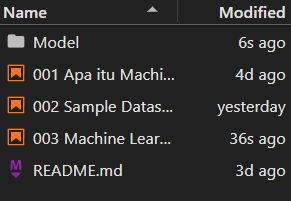

In [19]:
joblib.dump(model, 'Model/iris_knn_classifier.joblib')

['Model/iris_knn_classifier.joblib']

Setelah kita run code diatas, kita masuk ke folder `Model` dan bisa dilihat sudah ada file baru bernama `iris_classifier_knn.joblib`

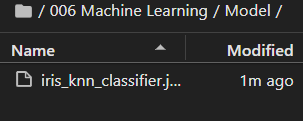

Ya walaupun sebenarnya file tersebut akan diminta oleh Tim Deployment atau Tim Production untuk diletakan dalam server. 

## Loading Model Machine Learning dari file `joblib`

Anggaplah kita orang bagian Production, kita sudah memindahkannya ke Server dan kita ingin mengakses bahkan menggunakan hasil model machine learning tadi. Caranya cukup mudah.

Kita bisa menyimpannya ke dalam variable terlebih dahulu semisal `production_model` lalu kita bisa load file joblib tadi.

In [20]:
production_model = joblib.load('Model/iris_knn_classifier.joblib')

Untuk mengetes hasil dari model, ya bisa kita lakukan seperti diatas tadi :

In [21]:
# 1. Siapkan data bunga baru (contoh: sepal length, sepal width, petal length, petal width)
# Penting: Data harus dalam bentuk array 2D [ [data] ]
data_baru = [[5.1, 3.5, 1.4, 0.2]] 

# 2. Gunakan model yang sudah di-load untuk memprediksi
hasil = production_model.predict(data_baru)

# 3. Tampilkan hasilnya (masih berupa angka indeks)
print(f"Prediksi indeks: {hasil}")

# 4. Ubah ke nama spesies asli agar manusia paham
spesies = iris.target_names[hasil][0]
print(f"Bunga tersebut diprediksi sebagai spesies: {spesies}")

Prediksi indeks: [0]
Bunga tersebut diprediksi sebagai spesies: setosa
